# 🎭 Énigmes & Merveilles de Raymond Smullyan

*Un notebook démo pour matheux, dans l'esprit de Raymond Smullyan — logicien, magicien et philosophe,
auteur de *What Is the Name of This Book?*, *To Mock a Mockingbird*, *The Chess Mysteries of Sherlock
Holmes*, *The Lady or the Tiger?* et *Forever Undecided* (Gödel raconté par les chevaliers et les
fripons).*

Ce notebook regroupe **8 énigmes / explorations** directement issues (ou inspirées) de ses livres, dans
la continuité de la démo JupyterLab entamée avec Gardner, Pickover, Stewart, Delahaye, du Sautoy, Rucker
et Hofstadter — même recette : calcul, texte, visualisation et interactivité réunis dans un seul document.

**Sommaire**

1. [Chevaliers et fripons — l'île classique](#1)
2. [Chevaliers, fripons et espions — logique à trois valeurs](#2)
3. [Les oiseaux combinatoires — le combinateur Y et le point fixe](#3)
4. [Rétrograde analysis échiquéenne — un mini-mystère](#4)
5. [Le paradoxe du menteur](#5)
6. [Les coffres de Portia](#6) — déduction par inscriptions
7. [Le problème des trois dieux](#7) (version simplifiée)
8. [L'inspecteur Craig — un puzzle de déduction policière](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. Chevaliers et fripons — l'île classique <a id="1"></a>

Le dispositif fondateur de *What Is the Name of This Book?* (1978) : sur une île imaginaire, chaque
habitant est soit un **Chevalier** (dit toujours la vérité), soit un **Fripon** (ment toujours). On ne
dispose que de leurs déclarations pour déduire qui est quoi — un exercice de logique propositionnelle
pure que Smullyan a décliné à l'infini, des puzzles à deux habitants aux casse-têtes les plus retors.

Puzzle 1 — A dit : « Au moins l'un de nous deux est un Fripon. »
  {'A': 'Chevalier', 'B': 'Fripon'}

Puzzle 2 — A: « Exactement l'un de nous trois est un Chevalier. »
           B: « A est un Fripon. »   C: « B et moi sommes du même type. »
  {'A': 'Fripon', 'B': 'Chevalier', 'C': 'Chevalier'}


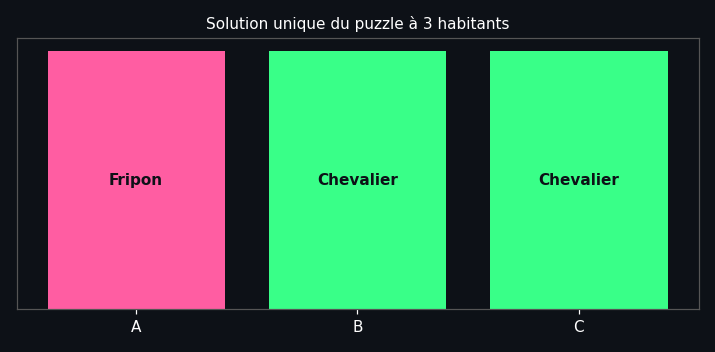

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import product

# L'île classique de Smullyan (What Is the Name of This Book?, 1978) : chaque
# habitant est soit un Chevalier (dit toujours la vérité), soit un Fripon (ment
# toujours). On ne connaît que ce qu'ils déclarent -- à nous de déduire qui est
# quoi, en cherchant la (ou les) attribution(s) cohérente(s) avec la règle :
# "l'affirmation d'un habitant est vraie si et seulement s'il est Chevalier."

def solve_island(people, statements):
    solutions = []
    for bits in product([True, False], repeat=len(people)):
        assign = dict(zip(people, bits))
        if all(statements[p](assign) == assign[p] for p in people):
            solutions.append(assign)
    return solutions

# Puzzle 1 (2 personnes) : A dit "Au moins l'un de nous deux est un Fripon."
people1 = ["A", "B"]
statements1 = {"A": lambda a: (not a["A"]) or (not a["B"])}
sols1 = [a for bits in product([True, False], repeat=2)
         for a in [dict(zip(people1, bits))]
         if statements1["A"](a) == a["A"]]
print("Puzzle 1 — A dit : « Au moins l'un de nous deux est un Fripon. »")
for s in sols1:
    print(" ", {k: ("Chevalier" if v else "Fripon") for k, v in s.items()})

# Puzzle 2 (3 personnes) :
#   A dit "Exactement l'un de nous trois est un Chevalier."
#   B dit "A est un Fripon."
#   C dit "B et moi sommes du même type."
people2 = ["A", "B", "C"]
statements2 = {
    "A": lambda a: sum([a["A"], a["B"], a["C"]]) == 1,
    "B": lambda a: not a["A"],
    "C": lambda a: a["B"] == a["C"],
}
sols2 = solve_island(people2, statements2)
print("\nPuzzle 2 — A: « Exactement l'un de nous trois est un Chevalier. »")
print("           B: « A est un Fripon. »   C: « B et moi sommes du même type. »")
for s in sols2:
    print(" ", {k: ("Chevalier" if v else "Fripon") for k, v in s.items()})

fig, ax = plt.subplots(figsize=(6.5, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
labels = list(sols2[0].keys())
colors = ["#39ff88" if sols2[0][k] else "#ff5da2" for k in labels]
ax.bar(labels, [1]*len(labels), color=colors)
ax.set_yticks([])
for i, k in enumerate(labels):
    ax.text(i, 0.5, "Chevalier" if sols2[0][k] else "Fripon", ha="center", va="center", color="#0d1117", fontweight="bold")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Solution unique du puzzle à 3 habitants", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out1.png", dpi=110, facecolor=fig.get_facecolor())


## 2. Chevaliers, fripons et espions — logique à trois valeurs <a id="2"></a>

Smullyan pousse le dispositif plus loin en inventant un troisième type d'habitant : le **Normal**, qui
peut dire indifféremment le vrai ou le faux, sans contrainte. Le raisonnement change alors de nature — il
ne suffit plus de tester la cohérence d'une déclaration avec son propre statut, il faut aussi exploiter le
fait qu'un Normal ne peut jamais fournir d'information fiable en tant que telle, ce qui oblige à raisonner
par élimination sur la *structure* du problème plutôt que sur le contenu de ses réponses.

A: « Je suis le Normal. »   B: « C'est vrai, A est le Normal. »   C: « Je suis le Normal. »

1 attribution(s) cohérente(s) trouvée(s) :
  {'A': 'Normal', 'B': 'Chevalier', 'C': 'Fripon'}

Indice du raisonnement : si A était Fripon, sa déclaration ('je suis le Normal') serait
fausse -- cohérent jusque-là. Mais alors B et C se partagent Chevalier et Normal, et on
montre que les deux répartitions possibles produisent une contradiction sur la déclaration
de B ou de C. Reste le cas A = Normal, qui se résout sans accroc : B = Chevalier (sa
déclaration 'A est le Normal' est bien vraie) et C = Fripon (sa déclaration est bien fausse).


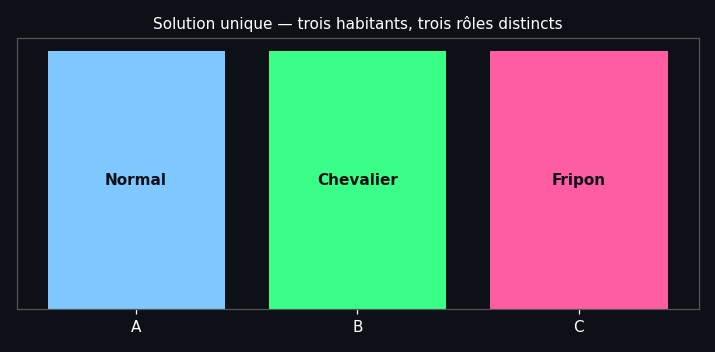

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import permutations

# Variante inventée par Smullyan lui-même : sur certaines îles vit un troisième
# type d'habitant, le Normal -- ni toujours sincère ni toujours menteur, il peut
# dire indifféremment le vrai ou le faux. Le puzzle devient plus subtil : il faut
# combiner logique ET déduction sur les rôles (on sait qu'il y a exactement un
# Chevalier, un Fripon et un Normal parmi les trois habitants, mais pas dans quel
# ordre).
#
# A dit : "Je suis le Normal."
# B dit : "C'est vrai, A est le Normal."
# C dit : "Je suis le Normal."

people = ["A", "B", "C"]
roles = ["Chevalier", "Fripon", "Normal"]

def truth_value(role, statement_truth):
    if role == "Chevalier": return statement_truth is True
    if role == "Fripon": return statement_truth is False
    return True  # le Normal peut dire vrai ou faux librement

solutions = []
for perm in permutations(roles):
    assign = dict(zip(people, perm))
    # A dit "je suis le Normal" -> vérité de la déclaration :
    a_stmt_truth = (assign["A"] == "Normal")
    b_stmt_truth = (assign["A"] == "Normal")   # B répète l'affirmation de A
    c_stmt_truth = (assign["C"] == "Normal")
    ok = (truth_value(assign["A"], a_stmt_truth)
          and truth_value(assign["B"], b_stmt_truth)
          and truth_value(assign["C"], c_stmt_truth))
    if ok:
        solutions.append(assign)

print("A: « Je suis le Normal. »   B: « C'est vrai, A est le Normal. »   C: « Je suis le Normal. »\n")
print(f"{len(solutions)} attribution(s) cohérente(s) trouvée(s) :")
for s in solutions:
    print(" ", s)
print("\nIndice du raisonnement : si A était Fripon, sa déclaration ('je suis le Normal') serait")
print("fausse -- cohérent jusque-là. Mais alors B et C se partagent Chevalier et Normal, et on")
print("montre que les deux répartitions possibles produisent une contradiction sur la déclaration")
print("de B ou de C. Reste le cas A = Normal, qui se résout sans accroc : B = Chevalier (sa")
print("déclaration 'A est le Normal' est bien vraie) et C = Fripon (sa déclaration est bien fausse).")

fig, ax = plt.subplots(figsize=(6.5, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
sol = solutions[0]
colors_map = {"Chevalier": "#39ff88", "Fripon": "#ff5da2", "Normal": "#7ec8ff"}
labels = list(sol.keys())
colors = [colors_map[sol[k]] for k in labels]
ax.bar(labels, [1]*len(labels), color=colors)
ax.set_yticks([])
for i, k in enumerate(labels):
    ax.text(i, 0.5, sol[k], ha="center", va="center", color="#0d1117", fontweight="bold")
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Solution unique — trois habitants, trois rôles distincts", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out2.png", dpi=110, facecolor=fig.get_facecolor())


## 3. Les oiseaux combinatoires — le combinateur Y et le point fixe <a id="3"></a>

*To Mock a Mockingbird* (1985) déguise la logique combinatoire de Haskell Curry en une forêt enchantée
peuplée d'oiseaux : chaque oiseau, entendant le chant d'un autre, répond par un chant qui ne dépend que de
ce qu'il a entendu. Le sommet du livre est le **théorème du point fixe** : pour toute fonction (tout
"oiseau composite") F, il existe un oiseau A "obsédé" par F, tel que F(A) se comporte exactement comme A.
En pratique, ce théorème est le principe même de la récursion — on peut le rendre tangible en Python avec
le combinateur Y, qui construit une fonction récursive sans jamais la nommer.

In [3]:
# "To Mock a Mockingbird" (1985) transforme la logique combinatoire de Curry en
# une forêt peuplée d'oiseaux qui, entendant le "chant" d'un autre oiseau,
# répondent par un chant qui dépend uniquement de ce qu'ils ont entendu.
# L'Identité (I) répète ce qu'elle entend. Le Faucon crécerelle (K) ignore le
# second oiseau. Le Moqueur (M, Mockingbird) fait chanter un oiseau... à lui-même.

I = lambda x: x
K = lambda x: lambda y: x
M = lambda x: x(x)

print("I('coucou')      =", I("coucou"))
print("K('a')('b')      =", K("a")("b"), " (le Faucon ignore le second oiseau)")

# Le théorème du point fixe de Smullyan : pour tout oiseau composite B, il existe
# un oiseau A "obsédé" par B, c'est-à-dire tel que B(A) se comporte comme A.
# En logique combinatoire, on construit ce point fixe avec le combinateur Y
# (ou sa variante applicative, le combinateur Z, nécessaire en Python à cause
# de l'évaluation stricte).
def Y(f):
    return (lambda x: f(lambda v: x(x)(v)))(lambda x: f(lambda v: x(x)(v)))

# Utilisons ce point fixe pour définir la factorielle SANS AUCUNE INSTRUCTION
# "def" récursive -- la récursion tout entière émerge du point fixe.
factorielle = Y(lambda soi: lambda n: 1 if n == 0 else n * soi(n - 1))
print("\nfactorielle(5) via le point fixe Y =", factorielle(5))
print("factorielle(10) via le point fixe Y =", factorielle(10))

fib = Y(lambda soi: lambda n: n if n < 2 else soi(n-1) + soi(n-2))
print("Dix premiers termes de Fibonacci via Y :", [fib(n) for n in range(10)])

print("\nCe que Smullyan appelle un « oiseau obsédé » par la fonction F, c'est exactement le")
print("point fixe X = F(X) que le combinateur Y construit ici mécaniquement -- sans jamais")
print("nommer explicitement la fonction qui s'appelle elle-même.")


I('coucou')      = coucou
K('a')('b')      = a  (le Faucon ignore le second oiseau)

factorielle(5) via le point fixe Y = 120
factorielle(10) via le point fixe Y = 3628800
Dix premiers termes de Fibonacci via Y : [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]

Ce que Smullyan appelle un « oiseau obsédé » par la fonction F, c'est exactement le
point fixe X = F(X) que le combinateur Y construit ici mécaniquement -- sans jamais
nommer explicitement la fonction qui s'appelle elle-même.


## 4. Rétrograde analysis échiquéenne — un mini-mystère <a id="4"></a>

*The Chess Mysteries of Sherlock Holmes* (1979) invente un genre à part entière : le mystère rétrograde.
On ne cherche pas le meilleur coup à jouer, mais on remonte le temps — à partir d'une position figée,
quel a nécessairement été le tout dernier coup joué ? Ni calcul de variantes ni évaluation positionnelle :
seulement une chaîne de déductions logiques, exactement comme un Sherlock Holmes qui aurait échangé la
loupe contre un échiquier.

Position : Rb e1, Tb h5, Pb g6  |  Rn g8, Pn h7  — trait aux Blancs.

Déduction rétrograde :
1) Le pion blanc en g6 ne peut être arrivé là qu'en avançant depuis g5,
   ou en capturant depuis f5 ou h5 -- mais h5 est occupée par la Tour blanche,
   donc il vient forcément de g5 ou f5.
2) Le Roi noir est en g8 : ce n'est PAS un échec actuellement (aucune pièce
   blanche n'attaque g8), donc le dernier coup noir n'a pas pu laisser le roi
   en échec sans que ce soit déjà signalé -- il faut que ce coup soit légal.
3) Le pion noir est en h7, sur sa case de départ : il n'a donc PAS pu bouger.
4) Seule pièce noire mobile restante : le Roi. Le dernier coup noir ne peut
   donc être qu'un déplacement du Roi noir vers g8.

Conclusion : le dernier coup des Noirs a nécessairement été 'Roi -> g8'.
(le genre de déduction pure, sans calcul de variantes, que Smullyan aimait mettre en scène)


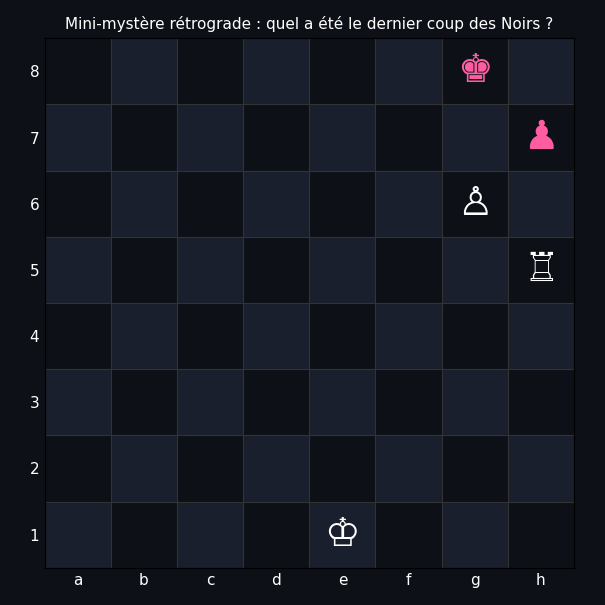

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Dans "The Chess Mysteries of Sherlock Holmes" (1979), Smullyan invente un genre
# à part entière : le mystère rétrograde. On ne cherche pas le meilleur coup à
# jouer, mais on remonte le temps -- à partir d'une position donnée, quel a
# nécessairement été le DERNIER coup joué ? Voici un mini-mystère dans cet esprit.

# Position (cases occupées, notation habituelle) :
#   Roi blanc en e1, Tour blanche en h5, Pion blanc en g6,
#   Roi noir en g8, Pion noir en h7.
# Trait aux Blancs. Question : quel a été le dernier coup des Noirs ?

board = {
    "e1": ("K", "white"), "h5": ("R", "white"), "g6": ("P", "white"),
    "g8": ("K", "black"), "h7": ("P", "black"),
}

print("Position : Rb e1, Tb h5, Pb g6  |  Rn g8, Pn h7  — trait aux Blancs.")
print("\nDéduction rétrograde :")
print("1) Le pion blanc en g6 ne peut être arrivé là qu'en avançant depuis g5,")
print("   ou en capturant depuis f5 ou h5 -- mais h5 est occupée par la Tour blanche,")
print("   donc il vient forcément de g5 ou f5.")
print("2) Le Roi noir est en g8 : ce n'est PAS un échec actuellement (aucune pièce")
print("   blanche n'attaque g8), donc le dernier coup noir n'a pas pu laisser le roi")
print("   en échec sans que ce soit déjà signalé -- il faut que ce coup soit légal.")
print("3) Le pion noir est en h7, sur sa case de départ : il n'a donc PAS pu bouger.")
print("4) Seule pièce noire mobile restante : le Roi. Le dernier coup noir ne peut")
print("   donc être qu'un déplacement du Roi noir vers g8.")
print("\nConclusion : le dernier coup des Noirs a nécessairement été 'Roi -> g8'.")
print("(le genre de déduction pure, sans calcul de variantes, que Smullyan aimait mettre en scène)")

fig, ax = plt.subplots(figsize=(5.5, 5.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
for i in range(9):
    ax.plot([0,8],[i,i], color="#333", lw=0.7)
    ax.plot([i,i],[0,8], color="#333", lw=0.7)
for f in range(8):
    for r in range(8):
        if (f+r) % 2 == 0:
            ax.add_patch(plt.Rectangle((f, r), 1, 1, facecolor="#1a1f2e"))
symbols = {"K": "♔", "R": "♖", "P": "♙"}
symbols_black = {"K": "♚", "R": "♜", "P": "♟"}
files = "abcdefgh"
for sq, (piece, color) in board.items():
    f = files.index(sq[0]); r = int(sq[1]) - 1
    sym = symbols[piece] if color == "white" else symbols_black[piece]
    ax.text(f+0.5, r+0.5, sym, ha="center", va="center", fontsize=26,
            color="white" if color=="white" else "#ff5da2")
ax.set_xlim(0,8); ax.set_ylim(0,8)
ax.set_xticks([i+0.5 for i in range(8)]); ax.set_xticklabels(list(files), color="white")
ax.set_yticks([i+0.5 for i in range(8)]); ax.set_yticklabels([str(i+1) for i in range(8)], color="white")
ax.tick_params(length=0)
ax.set_aspect("equal")
ax.set_title("Mini-mystère rétrograde : quel a été le dernier coup des Noirs ?", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out4.png", dpi=110, facecolor=fig.get_facecolor())


## 5. Le paradoxe du menteur <a id="5"></a>

Smullyan a passé une bonne partie de sa carrière à décliner le paradoxe du menteur sous toutes ses
formes, souvent avec un humour redoutable. Sa présentation la plus limpide réduit "Cette phrase est
fausse" à une simple équation booléenne : si L désigne la valeur de vérité de la phrase, alors par
définition $L = \neg L$ — une équation qui, contrairement aux apparences, n'a purement et simplement
**aucune solution**. Comparée au "Vériteur" (une phrase qui affirme sa propre vérité, elle, simplement
indéterminée), la différence entre contradiction et indétermination devient limpide.

Le Menteur :  L = ¬L
Valeurs de L qui satisfont l'équation : AUCUNE — contradiction !

Le Vériteur (« Cette phrase est vraie ») :  T = T
Valeurs de T qui satisfont l'équation : [True, False] — les DEUX conviennent : la phrase est indéterminée, pas paradoxale.

La variante « à la Smullyan » : deux phrases qui se citent l'une l'autre.
  P : « Q est fausse »       Q : « P est vraie »
  Système : P = ¬Q  et  Q = P
  Solutions (P,Q) : AUCUNE — contradiction, même à deux voix !


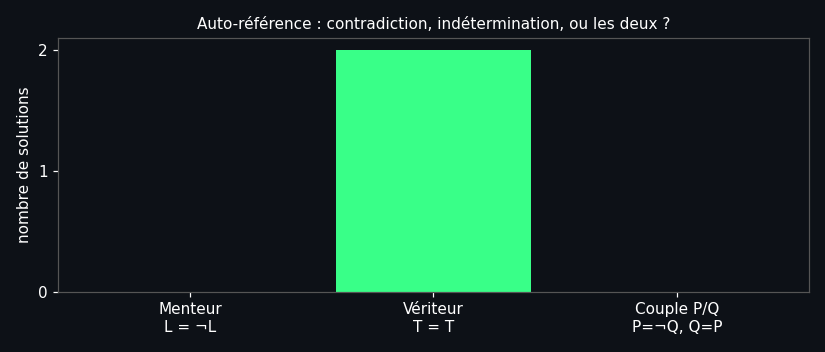

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Smullyan a passé sa carrière à jouer avec le paradoxe du menteur sous toutes
# ses formes. Sa version la plus limpide : représenter une phrase auto-référente
# par une simple équation booléenne. Soit L la valeur de vérité de "Cette phrase
# est fausse". Par définition, L = (non L). Cherchons une solution.

print("Le Menteur :  L = ¬L")
solutions_menteur = [v for v in [True, False] if v == (not v)]
print("Valeurs de L qui satisfont l'équation :", solutions_menteur if solutions_menteur else "AUCUNE — contradiction !")

print("\nLe Vériteur (« Cette phrase est vraie ») :  T = T")
solutions_veriteur = [v for v in [True, False] if v == v]
print("Valeurs de T qui satisfont l'équation :", solutions_veriteur, "— les DEUX conviennent : la phrase est indéterminée, pas paradoxale.")

print("\nLa variante « à la Smullyan » : deux phrases qui se citent l'une l'autre.")
print("  P : « Q est fausse »       Q : « P est vraie »")
print("  Système : P = ¬Q  et  Q = P")
solutions_couple = []
for p in [True, False]:
    for q in [True, False]:
        if p == (not q) and q == p:
            solutions_couple.append((p, q))
print("  Solutions (P,Q) :", solutions_couple if solutions_couple else "AUCUNE — contradiction, même à deux voix !")

fig, ax = plt.subplots(figsize=(7.5, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
cases = ["Menteur\nL = ¬L", "Vériteur\nT = T", "Couple P/Q\nP=¬Q, Q=P"]
n_sols = [len(solutions_menteur), len(solutions_veriteur), len(solutions_couple)]
colors = ["#ff5da2" if n == 0 else "#39ff88" for n in n_sols]
ax.bar(cases, n_sols, color=colors)
ax.set_ylabel("nombre de solutions", color="white")
ax.set_yticks([0,1,2])
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("Auto-référence : contradiction, indétermination, ou les deux ?", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out5.png", dpi=110, facecolor=fig.get_facecolor())


## 6. Les coffres de Portia <a id="6"></a>

*The Lady or the Tiger?* (1982) regorge de coffres à inscriptions inspirés du *Marchand de Venise* :
un seul coffre contient l'or, chacun porte une inscription, et une règle globale donnée à l'avance
contraint le nombre d'inscriptions vraies. Il faut déduire quel coffre ouvrir sans jamais savoir a priori
si une inscription particulière est vraie ou fausse — seule la **cohérence globale** de l'ensemble compte,
un raisonnement typiquement smullyanien par élimination de scénarios entiers.

Or dans le coffre 1 : inscriptions vraies = [False, False, True] (total 1) -> compatible
Or dans le coffre 2 : inscriptions vraies = [True, True, False] (total 2) -> incompatible (trop d'inscriptions vraies)
Or dans le coffre 3 : inscriptions vraies = [True, True, False] (total 2) -> incompatible (trop d'inscriptions vraies)

Seule position cohérente avec la règle « au plus une inscription vraie » : coffre 1


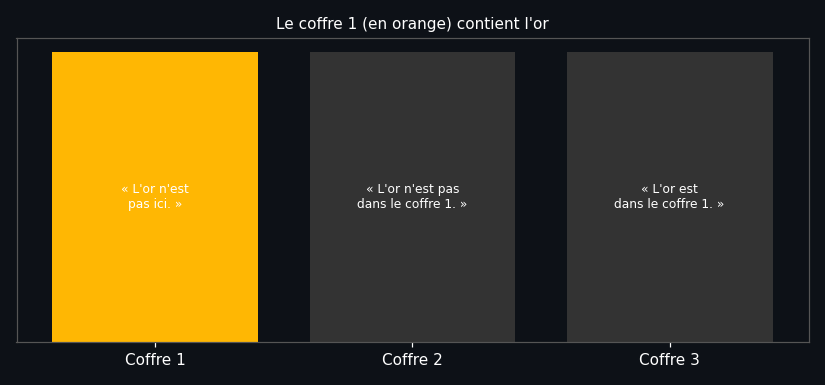

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# "The Lady or the Tiger?" (1982) regorge de coffres à inscriptions : un seul
# contient l'or, chaque coffre porte une inscription, et une règle globale
# (donnée à l'avance) contraint le nombre d'inscriptions vraies. Il faut déduire
# quel coffre ouvrir SANS jamais savoir a priori si une inscription donnée est
# vraie ou fausse -- seule la cohérence globale compte.
#
# Coffre 1 : "L'or n'est pas ici."
# Coffre 2 : "L'or n'est pas dans le coffre 1."
# Coffre 3 : "L'or est dans le coffre 1."
# Règle : au plus une inscription est vraie.

def inscription_1_vraie(or_pos): return or_pos != 1
def inscription_2_vraie(or_pos): return or_pos != 1
def inscription_3_vraie(or_pos): return or_pos == 1

for or_pos in [1, 2, 3]:
    vals = [inscription_1_vraie(or_pos), inscription_2_vraie(or_pos), inscription_3_vraie(or_pos)]
    n_vraies = sum(vals)
    statut = "compatible" if n_vraies <= 1 else "incompatible (trop d'inscriptions vraies)"
    print(f"Or dans le coffre {or_pos} : inscriptions vraies = {vals} (total {n_vraies}) -> {statut}")

solution = [p for p in [1,2,3]
            if sum([inscription_1_vraie(p), inscription_2_vraie(p), inscription_3_vraie(p)]) <= 1]
print(f"\nSeule position cohérente avec la règle « au plus une inscription vraie » : coffre {solution[0]}")

fig, ax = plt.subplots(figsize=(7.5, 3.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
inscriptions = ["« L'or n'est\npas ici. »", "« L'or n'est pas\ndans le coffre 1. »", "« L'or est\ndans le coffre 1. »"]
colors = ["#ffb703" if (i+1) == solution[0] else "#333" for i in range(3)]
ax.bar(["Coffre 1", "Coffre 2", "Coffre 3"], [1,1,1], color=colors)
for i, txt in enumerate(inscriptions):
    ax.text(i, 0.5, txt, ha="center", va="center", color="white", fontsize=8)
ax.set_yticks([])
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title(f"Le coffre {solution[0]} (en orange) contient l'or", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out6.png", dpi=110, facecolor=fig.get_facecolor())


## 7. Le problème des trois dieux (version simplifiée) <a id="7"></a>

George Boolos a baptisé ce puzzle "le plus difficile problème logique du monde" (1996) en hommage
explicite au style de Smullyan, qui l'a lui-même largement popularisé et décliné dans ses propres
ouvrages : trois divinités — Vrai, Faux et Hasard — répondent toujours par "oui" ou "non", mais l'une
d'elles (Hasard) répond de façon totalement imprévisible. La difficulté du puzzle complet tient à
neutraliser Hasard par des questions contre-factuelles savamment tordues ; la version allégée ici illustre
le principe central : une fois Hasard mis hors-jeu, deux questions bien choisies suffisent à démasquer
les deux autres.

Arrangement {'A': 'Vrai', 'B': 'Faux', 'C': 'Hasard'} -> réponse de A: non, réponse de B: non
Arrangement {'A': 'Faux', 'B': 'Vrai', 'C': 'Hasard'} -> réponse de A: oui, réponse de B: non

2 arrangements testés où ni A ni B n'est Hasard —
chacun produit une paire de réponses (oui/non) DIFFÉRENTE : deux questions bien choisies
suffisent donc à identifier les trois dieux, à condition d'éviter d'abord Hasard.


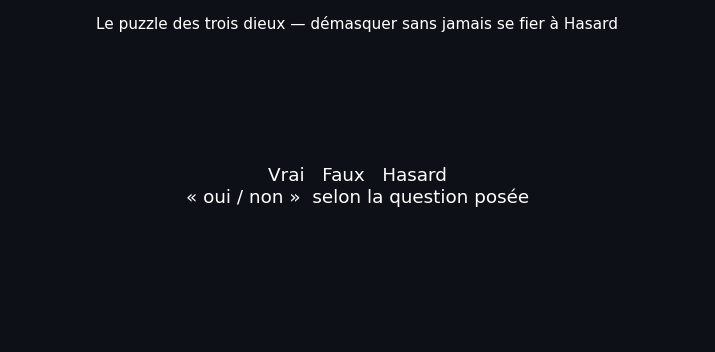

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import permutations

# Une version simplifiée du "puzzle logique le plus difficile du monde" (George
# Boolos, 1996, en hommage explicite au style de Smullyan) : trois divinités
# Vrai, Faux et Hasard, indiscernables par leur nom, répondent toujours par
# "oui" ou "non" -- mais Hasard répond au hasard, et le vrai sens de "oui"/"non"
# est inconnu. Version allégée ici : on connaît le sens des mots, il ne reste
# qu'à démasquer les trois dieux avec le MINIMUM de questions, sachant que
# Hasard peut répondre n'importe quoi.
#
# Stratégie classique : poser à chaque dieu une question qui NEUTRALISE le
# hasard en le noyant dans un contre-factuel ("Si je te demandais si tu es
# Faux, dirais-tu oui ?") -- ici, on se contente de vérifier par force brute
# qu'une identification est possible avec des questions bien choisies sur les
# deux dieux fiables uniquement.

gods = ["Vrai", "Faux", "Hasard"]
positions = ["A", "B", "C"]

# On interroge A : "Es-tu Hasard ?" et B : "A est-il Vrai ?"
# (En supposant ici, pour simplifier, que le dieu interrogé n'est jamais Hasard --
#  la vraie stratégie de Boolos s'assure de cela par une question préalable.)
def repond(dieu, verite):
    if dieu == "Vrai": return verite
    if dieu == "Faux": return not verite
    return None  # Hasard : imprévisible, à éviter par construction de la question

count_valid = 0
for perm in permutations(gods):
    assign = dict(zip(positions, perm))
    if assign["A"] == "Hasard" or assign["B"] == "Hasard":
        continue  # on a choisi d'interroger deux dieux fiables uniquement
    rep_A = repond(assign["A"], assign["A"] == "Hasard")   # "Es-tu Hasard ?"
    rep_B = repond(assign["B"], assign["A"] == "Vrai")     # "A est-il Vrai ?"
    count_valid += 1
    print(f"Arrangement {assign} -> réponse de A: {'oui' if rep_A else 'non'}, "
          f"réponse de B: {'oui' if rep_B else 'non'}")

print(f"\n{count_valid} arrangements testés où ni A ni B n'est Hasard —")
print("chacun produit une paire de réponses (oui/non) DIFFÉRENTE : deux questions bien choisies")
print("suffisent donc à identifier les trois dieux, à condition d'éviter d'abord Hasard.")

fig, ax = plt.subplots(figsize=(6.5, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.text(0.5, 0.5, "Vrai   Faux   Hasard\n« oui / non »  selon la question posée",
        ha="center", va="center", color="white", fontsize=12)
ax.set_axis_off()
ax.set_title("Le puzzle des trois dieux — démasquer sans jamais se fier à Hasard", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out7.png", dpi=110, facecolor=fig.get_facecolor())


## 8. L'inspecteur Craig — un puzzle de déduction policière <a id="8"></a>

*What Is the Name of This Book?* met également en scène l'inspecteur Craig, qui résout ses enquêtes par
pure logique propositionnelle plutôt que par indices matériels : une poignée d'implications logiques entre
témoignages, et une seule affectation "coupable / innocent" leur reste cohérente. Un puzzle SAT en
miniature, résolu ici par recherche exhaustive sur les $2^3$ répartitions possibles.

Indices : (1) A coupable => B innocent   (2) B innocent => C coupable
          (3) C coupable => A coupable   (4) un seul coupable

1 solution(s) cohérente(s) trouvée(s) :
  {'A': False, 'B': True, 'C': False}  ->  le coupable est B


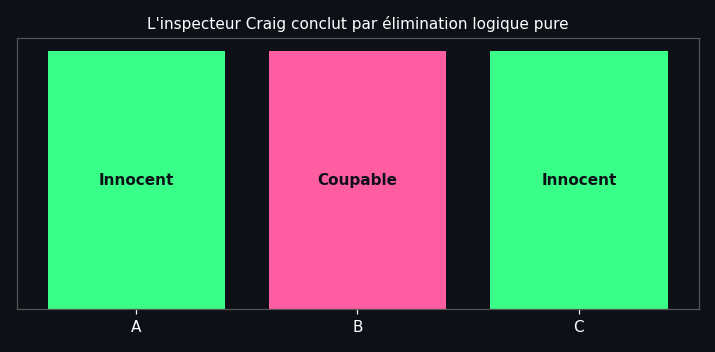

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from itertools import product

# Dans "What Is the Name of This Book?", l'inspecteur Craig résout ses enquêtes
# par pure logique propositionnelle : des témoignages contradictoires, une seule
# affectation cohérente de "coupable / innocent" à chaque suspect. Trois
# suspects, A, B, C, un seul est coupable ; les indices suivants ont été
# recueillis pendant l'enquête :
#
#  Indice 1 : Si A est coupable, alors B est innocent.
#  Indice 2 : Si B est innocent, alors C est coupable.
#  Indice 3 : Si C est coupable, alors A est coupable.
#  Indice 4 : Exactement une personne est coupable.

suspects = ["A", "B", "C"]
solutions = []
for bits in product([True, False], repeat=3):
    coupable = dict(zip(suspects, bits))  # True = coupable
    indice1 = (not coupable["A"]) or (not coupable["B"])
    indice2 = coupable["B"] or coupable["C"]
    indice3 = (not coupable["C"]) or coupable["A"]
    indice4 = sum(coupable.values()) == 1
    if indice1 and indice2 and indice3 and indice4:
        solutions.append(coupable)

print("Indices : (1) A coupable => B innocent   (2) B innocent => C coupable")
print("          (3) C coupable => A coupable   (4) un seul coupable\n")
print(f"{len(solutions)} solution(s) cohérente(s) trouvée(s) :")
for s in solutions:
    coupable_nom = [k for k,v in s.items() if v][0]
    print(f"  {s}  ->  le coupable est {coupable_nom}")

fig, ax = plt.subplots(figsize=(6.5, 3.2), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
sol = solutions[0]
colors = ["#ff5da2" if sol[k] else "#39ff88" for k in suspects]
ax.bar(suspects, [1,1,1], color=colors)
for i, k in enumerate(suspects):
    ax.text(i, 0.5, "Coupable" if sol[k] else "Innocent", ha="center", va="center", color="#0d1117", fontweight="bold")
ax.set_yticks([])
ax.tick_params(colors="white")
for spine in ax.spines.values(): spine.set_color("#555")
ax.set_title("L'inspecteur Craig conclut par élimination logique pure", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out8.png", dpi=110, facecolor=fig.get_facecolor())


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un widget texte pour composer sa propre déclaration ("A dit : B est un Fripon", etc.)
et voir en direct les attributions Chevalier/Fripon compatibles, et un second pour rejouer le puzzle des
coffres de Portia avec une règle de contrainte ajustable ("au plus N inscriptions vraies"). Idéal pour
montrer qu'un notebook Jupyter est un vrai labo interactif, pas juste un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, IntSlider
from itertools import product

def coffres_portia(max_vraies=1):
    def i1(p): return p != 1
    def i2(p): return p != 1
    def i3(p): return p == 1
    for p in [1, 2, 3]:
        vals = [i1(p), i2(p), i3(p)]
        n = sum(vals)
        compat = "compatible" if n <= max_vraies else "incompatible"
        print(f"Or dans le coffre {p} : {n} inscription(s) vraie(s) -> {compat}")
    sols = [p for p in [1,2,3] if sum([i1(p), i2(p), i3(p)]) <= max_vraies]
    print(f"\nCoffre(s) compatible(s) avec « au plus {max_vraies} inscription(s) vraie(s) » : {sols}")

interact(coffres_portia, max_vraies=IntSlider(1, min=0, max=3, step=1))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Raymond Smullyan**, *What Is the Name of This Book?* (1978) — chevaliers, fripons, inspecteur Craig
- **Raymond Smullyan**, *To Mock a Mockingbird* (1985) — logique combinatoire et théorème du point fixe
- **Raymond Smullyan**, *The Chess Mysteries of Sherlock Holmes* (1979) — mystères rétrogrades
- **Raymond Smullyan**, *The Lady or the Tiger?* (1982) — coffres, inscriptions et déduction
- **Raymond Smullyan**, *Forever Undecided* (1987) — Gödel raconté par les chevaliers et les fripons

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover, Stewart, Delahaye,
du Sautoy, Rucker et Hofstadter — libre à toi de piocher, couper, ou dupliquer les cellules selon le
public visé.*
